In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


In [2]:
import pandas as pd
import numpy as np

In [3]:
train = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')
test = pd.read_csv('/kaggle/input/competitions/titanic/test.csv')

In [4]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
print("Shape is:",train.shape)
print(train.info())
print(train.describe())

Shape is: (891, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     2

# Exploratory Data Analysis(EDA)

# Feature 1- Survived

In [6]:
print(train['Survived'].value_counts())
print(train["Survived"].value_counts(normalize=True))

Survived
0    549
1    342
Name: count, dtype: int64
Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


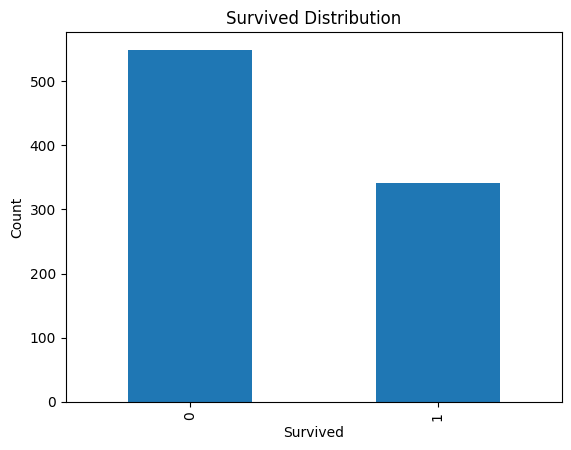

In [7]:
import matplotlib.pyplot as plt

train['Survived'].value_counts().plot(kind="bar")

plt.title("Survived Distribution")
plt.xlabel("Survived")
plt.ylabel("Count")
plt.show()

# Feature 2 - Sex

In [8]:
#Distribution of Sex

print(train["Sex"].value_counts())

print(pd.crosstab(train['Sex'] , train['Survived']))

pd.crosstab(
    train["Sex"],
    train["Survived"],
    normalize="index"
)

Sex
male      577
female    314
Name: count, dtype: int64
Survived    0    1
Sex               
female     81  233
male      468  109


Survived,0,1
Sex,,
female,0.257962,0.742038
male,0.811092,0.188908


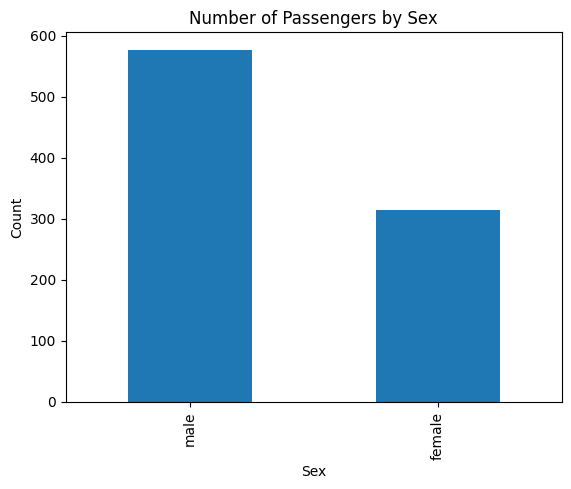

In [9]:
import matplotlib.pyplot as plt

# Count of males and females
train["Sex"].value_counts().plot(kind="bar")

plt.title("Number of Passengers by Sex")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.show()

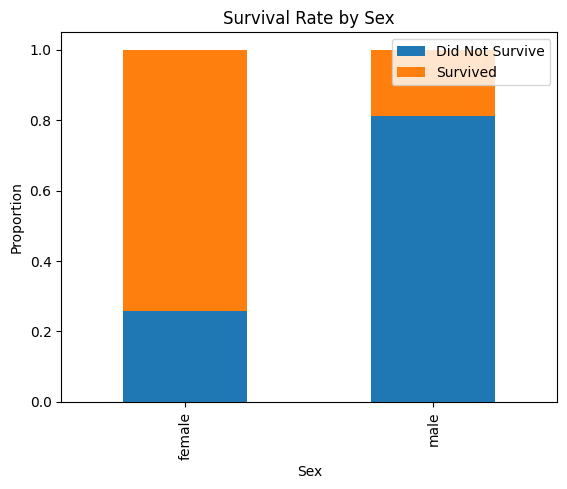

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Survival rate by sex
(
    pd.crosstab(train["Sex"], train["Survived"], normalize="index")
    .plot(kind="bar", stacked=True)
)

plt.title("Survival Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("Proportion")
plt.legend(["Did Not Survive", "Survived"])
plt.show()

# Feature 3 - Age

In [11]:
print(train["Age"].isnull().sum())
print(train["Age"].describe())

177
count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64


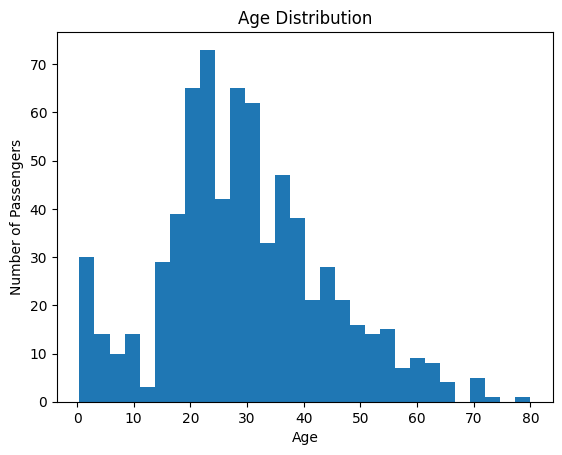

In [12]:
import matplotlib.pyplot as plt

train["Age"].plot(kind="hist", bins=30)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.show()

In [13]:
train.groupby("Survived")["Age"].describe()

,count,mean,std,min,25%,50%,75%,max
Survived,,,,,,,,
0,424.0,30.626179,14.172110,1.00,21.0,28.0,39.0,74.0
1,290.0,28.343690,14.950952,0.42,19.0,28.0,36.0,80.0


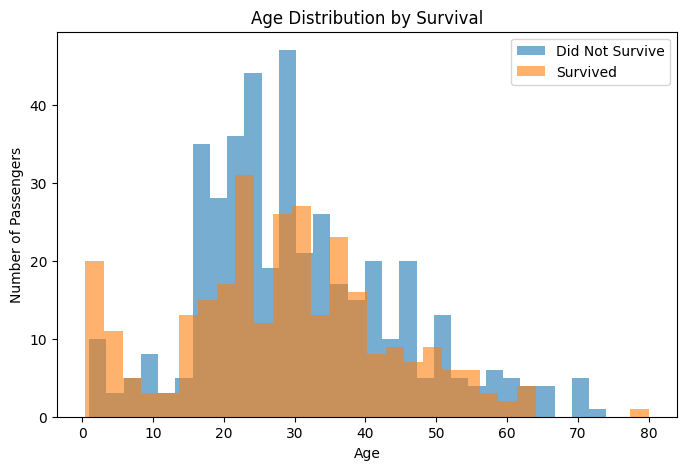

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

train[train["Survived"] == 0]["Age"].plot(
    kind="hist",
    bins=30,
    alpha=0.6,
    label="Did Not Survive"
)

train[train["Survived"] == 1]["Age"].plot(
    kind="hist",
    bins=30,
    alpha=0.6,
    label="Survived"
)

plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.title("Age Distribution by Survival")
plt.legend()
plt.show()

# Feature 4 - Pclass

In [15]:
pd.crosstab(train["Pclass"], train["Survived"])

Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119


In [16]:
pd.crosstab(train["Pclass"], train["Survived"], normalize="index")

Survived,0,1
Pclass,,
1,0.370370,0.629630
2,0.527174,0.472826
3,0.757637,0.242363


# Feature 5 — Fare

In [17]:
print(train["Fare"].describe())
print("Missing Value :",train["Fare"].isnull().sum())
print(train.groupby("Survived")["Fare"].describe())

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64
Missing Value : 0
          count       mean        std  min      25%   50%   75%       max
Survived                                                                 
0         549.0  22.117887  31.388207  0.0   7.8542  10.5  26.0  263.0000
1         342.0  48.395408  66.596998  0.0  12.4750  26.0  57.0  512.3292


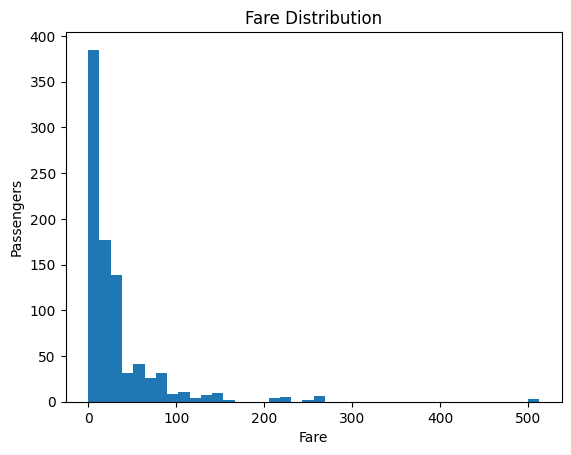

In [18]:
import matplotlib.pyplot as plt

train['Fare'].plot(kind="hist",bins=40)

plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Passengers")
plt.show()

# Feature 6 - Embarked

In [19]:
print("Missing Value : ",train["Embarked"].isnull().sum())
print(train["Embarked"].value_counts())

Missing Value :  2
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


In [20]:
print(pd.crosstab(train["Embarked"], train["Survived"]))
pd.crosstab(
    train["Embarked"],
    train["Survived"],
    normalize="index"
)

Survived    0    1
Embarked          
C          75   93
Q          47   30
S         427  217


Survived,0,1
Embarked,,
C,0.446429,0.553571
Q,0.610390,0.389610
S,0.663043,0.336957


# Feature 7 - SibSp (siblings/spouses aboard)

In [21]:
train["SibSp"].value_counts().sort_index()

SibSp
0    608
1    209
2     28
3     16
4     18
5      5
8      7
Name: count, dtype: int64

In [22]:
print(pd.crosstab(train["SibSp"], train["Survived"]))
pd.crosstab(
    train["SibSp"],
    train["Survived"],
    normalize="index"
)

Survived    0    1
SibSp             
0         398  210
1          97  112
2          15   13
3          12    4
4          15    3
5           5    0
8           7    0


Survived,0,1
SibSp,,
0,0.654605,0.345395
1,0.464115,0.535885
2,0.535714,0.464286
3,0.750000,0.250000
4,0.833333,0.166667
5,1.000000,0.000000
8,1.000000,0.000000


# Feature 8 - Parch (parents/children aboard)

In [23]:
train["Parch"].value_counts().sort_index()

Parch
0    678
1    118
2     80
3      5
4      4
5      5
6      1
Name: count, dtype: int64

In [24]:
print(pd.crosstab(train["Parch"], train["Survived"]))
pd.crosstab(
    train["Parch"],
    train["Survived"],
    normalize="index"
)

Survived    0    1
Parch             
0         445  233
1          53   65
2          40   40
3           2    3
4           4    0
5           4    1
6           1    0


Survived,0,1
Parch,,
0,0.656342,0.343658
1,0.449153,0.550847
2,0.500000,0.500000
3,0.400000,0.600000
4,1.000000,0.000000
5,0.800000,0.200000
6,1.000000,0.000000


# Text Feature Exploring

In [25]:
train["Name"].head(10)

0                              Braund, Mr. Owen Harris
1    Cumings, Mrs. John Bradley (Florence Briggs Th...
2                               Heikkinen, Miss. Laina
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                             Allen, Mr. William Henry
5                                     Moran, Mr. James
6                              McCarthy, Mr. Timothy J
7                       Palsson, Master. Gosta Leonard
8    Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)
9                  Nasser, Mrs. Nicholas (Adele Achem)
Name: Name, dtype: object

In [26]:
train["Ticket"].head(10)

0           A/5 21171
1            PC 17599
2    STON/O2. 3101282
3              113803
4              373450
5              330877
6               17463
7              349909
8              347742
9              237736
Name: Ticket, dtype: object

In [27]:
train["Cabin"].head(10)

0     NaN
1     C85
2     NaN
3    C123
4     NaN
5     NaN
6     E46
7     NaN
8     NaN
9     NaN
Name: Cabin, dtype: object

# Missing Value Handling

In [28]:
print(train["Embarked"].mode())
train["Embarked"] = train["Embarked"].fillna(train["Embarked"].mode()[0])
print(train["Embarked"].isnull().sum())

0    S
Name: Embarked, dtype: object
0


In [29]:
print(train["Age"].describe())
print(train["Age"].skew())

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64
0.38910778230082704


In [30]:
train["Age"] = train["Age"].fillna(train["Age"].median())
print(train["Age"].isnull().sum())

0


# Feature Engineering

In [31]:
#1 . Familysize
train["FamilySize"] = train["SibSp"] + train["Parch"] + 1
test["FamilySize"] = test["SibSp"] + test["Parch"] + 1
train[["SibSp", "Parch", "FamilySize"]].head(10)

,SibSp,Parch,FamilySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1
5,0,0,1
6,0,0,1
7,3,1,5
8,0,2,3
9,1,0,2


# Base Line Model

In [32]:
#Step 1: Select Features
features = [
    "Pclass",
    "Sex",
    "Age",        # New
    "Fare",
    "Embarked",   # New
    "SibSp",
    "Parch",
    "FamilySize"
]

In [33]:
#Step 2: Create X and y

X = train[features].copy()
y = train["Survived"]

In [34]:
print(X.head())

print(y.head())

print(X.shape)

print(y.shape)

   Pclass     Sex   Age     Fare Embarked  SibSp  Parch  FamilySize
0       3    male  22.0   7.2500        S      1      0           2
1       1  female  38.0  71.2833        C      1      0           2
2       3  female  26.0   7.9250        S      0      0           1
3       1  female  35.0  53.1000        S      1      0           2
4       3    male  35.0   8.0500        S      0      0           1
0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64
(891, 8)
(891,)


In [35]:
#Lable Encoding
X["Sex"] = X["Sex"].map({
    "male": 0,
    "female": 1
})

#one hot Encoding
X = pd.get_dummies(
    X,
    columns=["Embarked"],
    drop_first=True,
    dtype=int
)

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [37]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [38]:
y_pred = model.predict(X_valid)

In [39]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_valid, y_pred)

print(f"Validation Accuracy: {accuracy:.4f}")

Validation Accuracy: 0.8101


In [40]:
print(model.score(X_train, y_train))
print(model.score(X_valid, y_valid))

0.800561797752809
0.8100558659217877


# Final Model

In [41]:
final_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

final_model.fit(X, y)

LogisticRegression(max_iter=1000, random_state=42)

# Missing value at test set

In [42]:
X_test = test[features].copy()

X_test["Sex"] = X_test["Sex"].map({
    "male": 0,
    "female": 1
})

X_test = pd.get_dummies(
    X_test,
    columns=["Embarked"],
    drop_first=True,
    dtype=int
)


In [43]:
print(X.isnull().sum())
print(X_test.isnull().sum())

Pclass        0
Sex           0
Age           0
Fare          0
SibSp         0
Parch         0
FamilySize    0
Embarked_Q    0
Embarked_S    0
dtype: int64
Pclass         0
Sex            0
Age           86
Fare           1
SibSp          0
Parch          0
FamilySize     0
Embarked_Q     0
Embarked_S     0
dtype: int64


In [44]:
age_median = train["Age"].median()
X_test["Age"] = X_test["Age"].fillna(age_median)

fare_median = train["Fare"].median()
X_test["Fare"] = X_test["Fare"].fillna(fare_median)

In [45]:
print(X_test.isnull().sum())

Pclass        0
Sex           0
Age           0
Fare          0
SibSp         0
Parch         0
FamilySize    0
Embarked_Q    0
Embarked_S    0
dtype: int64


In [46]:
predictions = final_model.predict(X_test)

In [47]:
submission = pd.DataFrame({
    "PassengerId": test["PassengerId"],
    "Survived": predictions
})

submission.to_csv("submission_v4.1.csv", index=False)